<a href="https://colab.research.google.com/github/NikolayLenkovNikolaev/Forex_Finance/blob/main/Mapping_1v.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore")

#!pip install yfinance # Installing yfinance
#!pip install quantstats # Installing Quantstats
#!pip install pyportfolioopt # installing PyPortfolioOpt
#!pip install ta # Installing the TA (Technical Analysis) library
#!pip install pandas-datareader
#!pip install mplfinance

In [2]:
import yfinance as yf
import datetime as dt

start = dt.datetime(2000, 1, 1)
end  = dt.datetime.today()

df = yf.download("GC=F", start= start, end= end)

df.columns
df.columns = ['close', 'high', 'low', 'open', 'volume']
df.head()

# Create Column 1: 1 if the difference (col1 - col2) is positive, else 0
df['bear'] = (df['open'] - df['close']) > 0
df['bear'] = df['bear'].astype(int)

# Create Column 2: 1 if the difference (col1 - col2) is not positive, else 0
df['bull'] = (df['open'] - df['close']) <= 0
df['bull'] = df['bull'].astype(int)

df['body'] = abs(df['close'] - df['open'])
# Calculate the total candle size (difference between high and low)
df['range'] = df['high'] - df['low']

# Create 'up_shadow' column based on the condition
df['up_shadow']  = df.apply(lambda row: row['high'] - row['close'] if row['bull'] == 1 else 0, axis=1)
df['low_shadow'] = df.apply(lambda row: row['open'] - row['low']   if row['bull'] == 1 else 0, axis=1)

df.shape
df.head()
df.tail()

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])

,close,high,low,open,volume
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


(6114, 11)

,close,high,low,open,volume,bear,bull,body,range,up_shadow,low_shadow
Date,,,,,,,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0,0,1,0.0,0.0,0.0,0.0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0,0,1,3.5,3.5,0.0,0.0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0,0,1,0.0,0.0,0.0,0.0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2,0,1,0.0,0.0,0.0,0.0
2000-09-06,274.200012,274.200012,274.200012,274.200012,0,0,1,0.0,0.0,0.0,0.0


,close,high,low,open,volume,bear,bull,body,range,up_shadow,low_shadow
Date,,,,,,,,,,,
2025-01-07,2656.699951,2657.500000,2653.000000,2653.399902,643,0,1,3.300049,4.500000,0.800049,0.399902
2025-01-08,2664.500000,2676.899902,2653.500000,2655.500000,999,0,1,9.000000,23.399902,12.399902,2.000000
2025-01-09,2683.800049,2686.300049,2667.899902,2669.699951,1139,0,1,14.100098,18.400146,2.500000,1.800049
2025-01-10,2708.500000,2720.100098,2683.699951,2686.100098,1139,0,1,22.399902,36.400146,11.600098,2.400146
2025-01-13,2680.699951,2723.800049,2676.000000,2716.800049,176450,1,0,36.100098,47.800049,0.000000,0.000000


1-Candlestick:	Doji, Hanging Man, Inverted Hammer, Shooting Star, Spinning Top

2-Candlesticks:	Engulfing (Bullish/Bearish), Piercing Line, Dark Cloud Cover, Tweezer Tops, Tweezer Bottoms

3-Candlesticks:	Morning Star, Evening Star, Three White Soldiers, Three Black Crows, Tri-Star

4-Candlesticks:	Four-Price Doji, Deliberation

5-Candlesticks:	Five-Price Doji Star, Rising Three Methods, Falling Three
Methods

Complex/Rare:	Abandoned Baby, Harami

Doji ----Pattern----	Description	Significance
- Standard Doji:	Small body, long shadows on both sides.	Market indecision, possible reversal signal.
- Long-Legged Doji	Very long upper and lower shadows with a small body.	Strong indecision, potential reversal after trends.
- Dragonfly Doji	Small body at the top of the candlestick range, long lower shadow.	Potential bullish reversal after a downtrend.
- Gravestone Doji	Small body at the bottom of the candlestick range, long upper shadow.	Potential bearish reversal after an uptrend.
- Star Doji	Doji that gaps away from a large candlestick.	Potential trend reversal, especially with a gap.

## 1. Single Candlestick Patterns
These patterns are based on a single candlestick and indicate potential trend reversals or continuation.

### Bullish Candlestick Patterns:
- Hammer:
Description: Small body at the top of the candlestick with a long lower shadow. It signals potential reversal after a downtrend.
- Inverted Hammer:
Description: Small body at the bottom of the candlestick with a long upper shadow. It signals a potential reversal after a downtrend.
- Doji (Bullish Doji):
Description: The open and close are the same or nearly the same. A Doji after a downtrend suggests indecision and a potential reversal to the upside.
### Bearish Candlestick Patterns:
- Hanging Man:
Description: Small body at the top with a long lower shadow, appearing after an uptrend. It suggests a potential reversal to the downside.
- Shooting Star:
Description: Small body near the bottom with a long upper shadow, appearing after an uptrend. It signals a potential bearish reversal.
- Doji (Bearish Doji):
Description: The open and close are the same or nearly the same. A Doji after an uptrend suggests indecision and a potential reversal to the downside.
## 2. Two-Candlestick Patterns
### Bullish Candlestick Patterns:
- Bullish Engulfing:
Description: A small red (bearish) candlestick is followed by a large green (bullish) candlestick that completely engulfs the previous one. This signals a reversal to the upside.
- Piercing Line:
Description: A red (bearish) candlestick is followed by a green (bullish) candlestick that opens below the low of the previous candle and closes above its midpoint.
###Bearish Candlestick Patterns:
- Bearish Engulfing:
Description: A small green (bullish) candlestick is followed by a large red (bearish) candlestick that completely engulfs the previous one. This signals a reversal to the downside.
- Dark Cloud Cover:
Description: A green (bullish) candlestick is followed by a red (bearish) candlestick that opens above the high of the previous green candle and closes below its midpoint.

## 3. Three-Candlestick Patterns

### Bullish Candlestick Patterns:
- Morning Star:
Description: A three-bar pattern consisting of a long red (bearish) candlestick, a small-bodied candle (usually a Doji), and then a long green (bullish) candlestick. It signals a reversal to the upside after a downtrend.
- Three White Soldiers:
Description: Three consecutive long green (bullish) candlesticks that open within the previous candle’s body and close higher than the previous candle. This signals strong buying pressure and a reversal to the upside.
### Bearish Candlestick Patterns:
- Evening Star:
Description: A three-bar pattern consisting of a long green (bullish) candlestick, a small-bodied candle (usually a Doji), and then a long red (bearish) candlestick. It signals a reversal to the downside after an uptrend.
- Three Black Crows:
Description: Three consecutive long red (bearish) candlesticks that open within the previous candle’s body and close lower than the previous candle. This signals strong selling pressure and a reversal to the downside.

## 4. Four-Candlestick Patterns
These patterns involve four candlesticks and typically represent trend continuation or reversal.

### Bullish Candlestick Patterns:
- Rising Four Methods:
Description: A long green (bullish) candlestick followed by three small red (bearish) candlesticks, and then another long green candlestick. This pattern indicates that the uptrend is likely to continue.
###  Bearish Candlestick Patterns:
- Falling Four Methods:
Description: A long red (bearish) candlestick followed by three small green (bullish) candlesticks, and then another long red candlestick. This pattern indicates that the downtrend is likely to continue.
## 5. Complex or Rare Patterns (Combination of Candlesticks)
These are more complex patterns involving a combination of several candlesticks, often signaling powerful trend reversals or continuations.

### Bullish Candlestick Patterns:
- Morning Doji Star:
Description: A variation of the Morning Star pattern, but the middle candlestick is a Doji. It indicates indecision and a potential bullish reversal after a downtrend.
- Abandoned Baby:
Description: A rare bullish reversal pattern consisting of three candlesticks: a long red (bearish) candlestick, a gap (or Doji) candlestick, and then a long green (bullish) candlestick. It suggests a strong trend reversal to the upside.
### Bearish Candlestick Patterns:
- Evening Doji Star:
Description: A variation of the Evening Star pattern, but the middle candlestick is a Doji. It indicates indecision and a potential bearish reversal after an uptrend.
- Abandoned Baby:
Description: A rare bearish reversal pattern consisting of three candlesticks: a long green (bullish) candlestick, a gap (or Doji) candlestick, and then a long red (bearish) candlestick. It suggests a strong trend reversal to the downside.

In [3]:
# Function to identify Hammer candlestick pattern
def is_hammer(df):
    # Hammer conditions:
    # 1. Small body
    # 2. Long lower shadow
    # 3. Little or no upper shadow
    if (df["body"]       <= (df["range"] * 0.2) and
        df["low_shadow"] >= (df["body"]  * 0.2) and
        df["up_shadow"]  <= (df["body"]  * 0.1) and
        df["bull"] == 1
        ):
        return True
    return False

# Function to identify Inverted Hammer candlestick pattern
def is_inverted_hammer(df):
    # Inverted Hammer conditions:
    # 1. Small body
    # 2. Long upper shadow (at least twice the size of the body)
    # 3. Little or no lower shadow
    if (df["body"]       <= (0.2 * df["range"]) and
        df["up_shadow"]  >= (  2 * df["body"])  and
        df["low_shadow"] <= (0.1 * df["body"])  and
        df["bull"] == 1):
        return True
    return False

# Function to identify Hanging Man pattern
def is_hanging_man(row):
    # Hanging Man condition:
    # 1. Small body (body <= 10% of the range)
    # 2. Long lower shadow (lower shadow >= 2 * body)
    # 3. Short or no upper shadow (upper shadow <= 10% of the range)
    if (row['body']       <= (0.2 * row['range']) and
        row['low_shadow'] >= (  2 * row['body'])  and
        row['up_shadow']  <= (0.1 * row['range']) and
        row["bear"] == 1):
        return True
    return False

# Function to identify Shooting Star pattern
def is_shooting_star(row):
    # Shooting Star condition:
    # 1. Small body (body <= 10% of the range)
    # 2. Long upper shadow (upper shadow >= 2 * body)
    # 3. Short or no lower shadow (lower shadow <= 10% of the range)
    if (row['body']       <= (0.2 * row['range']) and
        row['up_shadow']  >= (2 * row['body'])    and
        row['low_shadow'] <= (0.1 * row['range']) and
        row["bear"] == 1):
        return True
    return False

# Apply the function to each row of the DataFrame to identify Hammer candlesticks
df['hammer'] = df.apply(is_hammer, axis=1)
df['hanging_man'] = df.apply(is_hanging_man, axis=1)
df['shooting_star'] = df.apply(is_shooting_star, axis=1)
df['inverted_hammer'] = df.apply(is_inverted_hammer, axis=1)





# Function to identify Standard Doji pattern
def is_standard_doji(row):
    # Standard Doji condition:
    # 1. Small body: Body should be <= 10% of the range (difference between High and Low)
    # 2. Non-zero upper and lower shadows (both should be present)
    if row['body'] <= (row['range'] * 0.1) and row['up_shadow'] > 0 and row['low_shadow'] > 0:
        return True
    return False

# Function to identify Long-Legged Doji pattern
def is_long_legged_doji(row):
    # Long-Legged Doji condition:
    # 1. Small body: Body should be <= 10% of the range (difference between High and Low)
    # 2. Long upper and lower shadows (at least twice the size of the body)
    if row['body'] <= (row['range'] * 0.1) and row['up_shadow'] >= (2 * row['body']) and row['low_shadow'] >= (2 * row['body']):
        return True
    return False

# Function to identify Dragonfly Doji pattern
def is_dragonfly_doji(row):
    # Dragonfly Doji condition:
    # 1. Small body (body <= 10% of the range)
    # 2. Long lower shadow (lower shadow >= 2 * body)
    # 3. Short or no upper shadow (upper shadow <= 10% of the range)
    if row['body'] <= (row['range'] * 0.1) and row['low_shadow'] >= (2 * row['body']) and row['up_shadow'] <= (0.1 * row['range']):
        return True
    return False

def is_gravestone_doji(row):
    # Gravestone Doji condition:
    # 1. Small body (body <= 10% of the range)
    # 2. Long upper shadow (upper shadow >= 2 * body)
    # 3. Short or no lower shadow (lower shadow <= 10% of the range)
    if row['body'] <= (row['range'] * 0.1) and row['up_shadow'] >= (2 * row['body']) and row['low_shadow'] <= (0.1 * row['range']):
        return True
    return False

# Apply the function to each row of the DataFrame to identify Standard Doji candlesticks
#df['standard_doji'] = df.apply(is_standard_doji, axis=1)
#df['long_legged_doji'] = df.apply(is_long_legged_doji, axis=1)
#df['dragonfly_doji'] = df.apply(is_dragonfly_doji, axis=1)
#df['gravestone_doji'] = df.apply(is_gravestone_doji, axis=1)

#df['standard_doji'].value_counts()
#df['long_legged_doji'].value_counts()
#df['dragonfly_doji'].value_counts()
#df['gravestone_doji'].value_counts()






# Create a new column to store Bullish Engulfing pattern identification
df['bullish_engulfing'] = False
# Create a new column to store Bearish Engulfing pattern identification
df['bearish_engulfing'] = False
# Create new columns to store pattern identification
df['dark_cloud_cover']  = False
df['piercing_line']     = False



# Function to identify Bullish Engulfing pattern
def is_bullish_engulfing(current, previous):
    # Condition for Bullish Engulfing:
    # 1. First (previous) candle is bearish (Close < Open)
    # 2. Second (current) candle is bullish (Close > Open)
    # 3. The second (current) candle engulfs the body of the first (previous) candle
    if previous['close'] < previous['open'] and current['close'] > current['open']:
        if current['open'] < previous['close'] and current['close'] > previous['open']:
            return True
    return False

# Function to identify Bearish Engulfing pattern
def is_bearish_engulfing(current, previous):
    # Condition for Bearish Engulfing:
    # 1. First (previous) candle is bullish (Close > Open)
    # 2. Second (current) candle is bearish (Close < Open)
    # 3. The second (current) candle engulfs the body of the first (previous) candle
    if previous['close'] > previous['open'] and current['close'] < current['open']:
        if current['open'] > previous['close'] and current['close'] < previous['open']:
            return True
    return False

# Function to identify Dark Cloud Cover pattern
def is_dark_cloud_cover(current, previous):
    # 1. The first (previous) candle is bullish (Close > Open)
    # 2. The second (current) candle is bearish (Close < Open)
    # 3. The second candle opens above the high of the first candle and closes below the midpoint of the first candle's body
    if previous['close'] > previous['open'] and current['close'] < current['open']:
        if current['open'] > previous['high'] and current['close'] < (previous['open'] + previous['close']) / 2:
            return True
    return False

# Function to identify Piercing Line pattern
def is_piercing_line(current, previous):
    # 1. The first (previous) candle is bearish (Close < Open)
    # 2. The second (current) candle is bullish (Close > Open)
    # 3. The second candle opens below the low of the first candle and closes above the midpoint of the first candle's body
    if previous['close'] < previous['open'] and current['close'] > current['open']:
        if current['open'] < previous['low'] and current['close'] > (previous['open'] + previous['close']) / 2:
            return True
    return False


# Iterate through the DataFrame to identify both patterns
for i in range(1, len(df)):
    df.loc[i, 'bullish_engulfing'] = is_bullish_engulfing(df.iloc[i], df.iloc[i-1])
    df.loc[i, 'bearish_engulfing'] = is_bearish_engulfing(df.iloc[i], df.iloc[i-1])
    df.loc[i, 'dark_cloud_cover']  = is_dark_cloud_cover(df.iloc[i], df.iloc[i-1])
    df.loc[i, 'piercing_line']     =    is_piercing_line(df.iloc[i], df.iloc[i-1])

#df = df[['bear', 'hammer', 'hanging_man','shooting_star', 'inverted_hammer', 'bullish_engulfing','bearish_engulfing', 'dark_cloud_cover', 'piercing_line', 'signal_bay','signal_sell']]
df["signal_bay"]  = 0
df["signal_sell"] = 0
df.loc[df["hammer"] == True,              "signal_bay"] = 1
df.loc[df['inverted_hammer'] == True,     "signal_bay"] = 1
df.loc[df['bullish_engulfing' ] == True,  "signal_bay"] = 1
df.loc[df['piercing_line' ] == True,      "signal_bay"] = 1

df.loc[df['hanging_man'] == True,         "signal_sell"] = 1
df.loc[df['shooting_star'] == True,       "signal_sell"] = 1
df.loc[df['bearish_engulfing'] == True,   "signal_sell"] = 1
df.loc[df['dark_cloud_cover'] == True,    "signal_sell"] = 1



In [4]:
for col in ['bear', 'bull',
        'hammer', 'hanging_man',
       'shooting_star', 'inverted_hammer', 'bullish_engulfing',
       'bearish_engulfing', 'dark_cloud_cover', 'piercing_line', 'signal_bay',
       'signal_sell']:
    print(f"------------{col}----------")
    df[col].value_counts()
    print("")
    print("------END ------")
    print("")


------------bear----------


,count
bear,
0.0,3630
1.0,2484



------END ------

------------bull----------


,count
bull,
1.0,3630
0.0,2484



------END ------

------------hammer----------


...


------END ------

------------signal_bay----------


,count
signal_bay,
0,11070
1,1157



------END ------

------------signal_sell----------


,count
signal_sell,
0,11999
1,228



------END ------



In [5]:
df['signal_lag_1_bay'] = df['signal_bay'].shift(1)  # 1-period lag
df['signal_lag_2_bay'] = df['signal_bay'].shift(2)  # 2-period lag
df['signal_lag_3_bay'] = df['signal_bay'].shift(3)  # 3-period lag

df['close_lag_1'] = df['close'].shift(1)  # 3-period lag]
df['close_lag_2'] = df['close'].shift(2)  # 2-period lag
df['close_lag_3'] = df['close'].shift(3)  # 3-period lag

df['signal_lag_1_sell'] = df['signal_sell'].shift(1)  # 1-period lag
df['signal_lag_2_sell'] = df['signal_sell'].shift(2)  # 2-period lag
df['signal_lag_3_sell'] = df['signal_sell'].shift(3)  # 3-period lag

#####################
df["target"] = 0

df.loc[(df['signal_lag_1_bay'] == 1) & (df['close'] > df['close_lag_1'])   , 'target'] = 1
df.loc[(df['signal_lag_2_bay'] == 1) & (df['close'] > df['close_lag_1'])   , 'target'] = 2
df.loc[(df['signal_lag_3_bay'] == 1) & (df['close'] > df['close_lag_1'])   , 'target'] = 3

df.loc[(df['signal_lag_1_sell'] == 1) & (df['close'] < df['close_lag_1'])   , 'target'] = 4
df.loc[(df['signal_lag_2_sell'] == 1) & (df['close'] < df['close_lag_1'])   , 'target'] = 5
df.loc[(df['signal_lag_3_sell'] == 1) & (df['close'] < df['close_lag_1'])   , 'target'] = 6

#df = df[['close', 'high', 'low', 'open', 'bear', 'bull',  'hammer', 'close_Lag_1', 'signal_bay', "signal_sell", 'signal_lag_1_bay', 'signal_lag_2_bay', 'signal_lag_3_bay', 'close_lag_1', 'close_lag_2', 'close_lag_3']]
df.head()

,close,high,low,open,volume,bear,bull,body,range,up_shadow,low_shadow,hammer,hanging_man,shooting_star,inverted_hammer,bullish_engulfing,bearish_engulfing,dark_cloud_cover,piercing_line,signal_bay,signal_sell,signal_lag_1_bay,signal_lag_2_bay,signal_lag_3_bay,close_lag_1,close_lag_2,close_lag_3,signal_lag_1_sell,signal_lag_2_sell,signal_lag_3_sell,target
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-08-30 00:00:00,273.899994,273.899994,273.899994,273.899994,0.0,0.0,1.0,0.0,0.0,0.0,0.0,True,False,False,True,False,False,False,False,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2000-08-31 00:00:00,278.299988,278.299988,274.799988,274.799988,0.0,0.0,1.0,3.5,3.5,0.0,0.0,False,False,False,False,False,False,False,False,0,0,1.0,NaN,NaN,273.899994,NaN,NaN,0.0,NaN,NaN,1
2000-09-01 00:00:00,277.000000,277.000000,277.000000,277.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,True,False,False,True,False,False,False,False,1,0,0.0,1.0,NaN,278.299988,273.899994,NaN,0.0,0.0,NaN,0
2000-09-05 00:00:00,275.799988,275.799988,275.799988,275.799988,2.0,0.0,1.0,0.0,0.0,0.0,0.0,True,False,False,True,False,False,False,False,1,0,1.0,0.0,1.0,277.000000,278.299988,273.899994,0.0,0.0,0.0,0
2000-09-06 00:00:00,274.200012,274.200012,274.200012,274.200012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,True,False,False,True,False,False,False,False,1,0,1.0,1.0,0.0,275.799988,277.000000,278.299988,0.0,0.0,0.0,0


In [6]:
df[df["hammer"]==True][:50]

,close,high,low,open,volume,bear,bull,body,range,up_shadow,low_shadow,hammer,hanging_man,shooting_star,inverted_hammer,bullish_engulfing,bearish_engulfing,dark_cloud_cover,piercing_line,signal_bay,signal_sell,signal_lag_1_bay,signal_lag_2_bay,signal_lag_3_bay,close_lag_1,close_lag_2,close_lag_3,signal_lag_1_sell,signal_lag_2_sell,signal_lag_3_sell,target
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-08-30 00:00:00,273.899994,273.899994,273.899994,273.899994,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2000-09-01 00:00:00,277.000000,277.000000,277.000000,277.000000,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,0.0,1.0,NaN,278.299988,273.899994,NaN,0.0,0.0,NaN,0
2000-09-05 00:00:00,275.799988,275.799988,275.799988,275.799988,2.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,0.0,1.0,277.000000,278.299988,273.899994,0.0,0.0,0.0,0
2000-09-06 00:00:00,274.200012,274.200012,274.200012,274.200012,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,0.0,275.799988,277.000000,278.299988,0.0,0.0,0.0,0
2000-09-07 00:00:00,274.000000,274.000000,274.000000,274.000000,125.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,1.0,274.200012,275.799988,277.000000,0.0,0.0,0.0,0
2000-09-08 00:00:00,273.299988,273.299988,273.299988,273.299988,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,1.0,274.000000,274.200012,275.799988,0.0,0.0,0.0,0
2000-09-11 00:00:00,273.100006,273.100006,273.100006,273.100006,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,1.0,273.299988,274.000000,274.200012,0.0,0.0,0.0,0
2000-09-12 00:00:00,272.899994,272.899994,272.899994,272.899994,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,1.0,273.100006,273.299988,274.000000,0.0,0.0,0.0,0
2000-09-13 00:00:00,272.799988,272.799988,272.799988,272.799988,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,True,False,False,True,False,False,False,False,1,0,1.0,1.0,1.0,272.899994,273.100006,273.299988,0.0,0.0,0.0,0


In [7]:
df["target"].value_counts()

,count
target,
0,11326
3,475
2,251
1,175


In [8]:
df["target"].value_counts()

,count
target,
0,11326
3,475
2,251
1,175


In [9]:
#df.loc[df['standard_doji']    == True,  "target"] = 99
#df.loc[df['long_legged_doji'] == True,  "target"] = 99
#df.loc[df['dragonfly_doji']   == True,  "target"] = 99
#df.loc[df['gravestone_doji']  == True,  "target"] = 99

0

Count where col-1 == col-2: 0
Count where col-1 != col-2: 1157


<Figure size 600x400 with 0 Axes>

<BarContainer object of 2 artists>

Text(0.5, 1.0, 'Count of Equal vs. Unequal Values in col-1 and col-2')

Text(0, 0.5, 'Count')

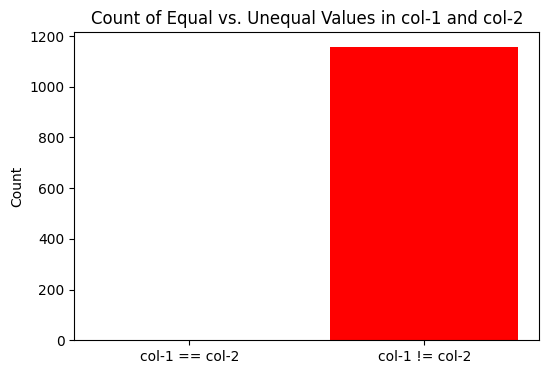

In [10]:
# Create a boolean mask where col-1 equals col-
df1 = df[df["signal_bay"]==1]
match = df1['signal_bay'] == df1['signal_sell']

# Count the number of True values (where col-1 == col-2)
count_equal = match.sum()
count_equal
# Count the number of False values (where col-1 != col-2)
count_unequal = (~match).sum()

# Print the counts
print(f"Count where col-1 == col-2: {count_equal}")
print(f"Count where col-1 != col-2: {count_unequal}")

# Visualize using a bar plot
plt.figure(figsize=(6, 4))
plt.bar(['col-1 == col-2', 'col-1 != col-2'], [count_equal, count_unequal], color=['green', 'red'])
plt.title('Count of Equal vs. Unequal Values in col-1 and col-2')
plt.ylabel('Count')
plt.show()

In [11]:
df1 = df[['bear', 'bull', 'hammer',  'inverted_hammer', 'bullish_engulfing', 'piercing_line', 'signal_bay','signal_sell']]
df1 = df1[df['signal_bay'] == 1]
filtered_df = df1[(df1['signal_bay'] == True) & (df1['signal_sell'] == True)]
df1.shape
filtered_df.shape
filtered_df.head(99)

(1157, 8)

(0, 8)

,bear,bull,hammer,inverted_hammer,bullish_engulfing,piercing_line,signal_bay,signal_sell
Date,,,,,,,,
